In [ ]:
import pandas as pd
from src.load_data import load
from pathlib import Path
import sys
import seaborn as sns 
import matplotlib.pyplot as plt 

ModuleNotFoundError: No module named 'src'

In [ ]:

#Searching the file and loading it 
cwd = Path.cwd()
print("Working directory:", cwd)

if (cwd / "src" / "load_data.py").exists():
    project_dir = cwd

elif (cwd.parent / "src" / "load_data.py").exists():
    project_dir = cwd.parent
else:
    raise FileNotFoundError("Cannot find src/load_data.py near the working directory")

sys.path.insert(0, str(project_dir))
print("Using project folder:", project_dir)

df = load()

#display the data from data frame
df.head()



Working directory: c:\Users\Administrator\Desktop\ironhack\Mini_Project\notebooks
Using project folder: c:\Users\Administrator\Desktop\ironhack\Mini_Project


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


In [ ]:
#Exploratory Data Analysis (EDA)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Unnamed: 0           640840 non-null  int64
 1   store_ID             640840 non-null  int64
 2   day_of_week          640840 non-null  int64
 3   date                 640840 non-null  str  
 4   nb_customers_on_day  640840 non-null  int64
 5   open                 640840 non-null  int64
 6   promotion            640840 non-null  int64
 7   state_holiday        640840 non-null  str  
 8   school_holiday       640840 non-null  int64
 9   sales                640840 non-null  int64
dtypes: int64(8), str(2)
memory usage: 55.6 MB


In [ ]:
#Display the rows and columns of the data frame
df.shape


(640840, 10)

In [ ]:
#display the column names of the data frame
df.columns

Index(['Unnamed: 0', 'store_ID', 'day_of_week', 'date', 'nb_customers_on_day',
       'open', 'promotion', 'state_holiday', 'school_holiday', 'sales'],
      dtype='str')

In [ ]:
#check for missing values in the data frame
df.isnull().sum()

Unnamed: 0             0
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64

In [ ]:
#describe the data frame
df.describe()

,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


#### Convert 'date' and 'state_holiday' columns into numeric features 

In [4]:
df['state_holiday'] = df['state_holiday'].astype(str)
df['state_holiday'].unique()

array(['0', 'a', 'c', 'b'], dtype=object)

In [5]:
df.groupby("state_holiday")["sales"].mean()

state_holiday
0    5952.206403
a     282.368167
b     252.936877
c     178.606707
Name: sales, dtype: float64

##### It is clear that the zero value has a high impact on sales, so we encode the column and keep it.

In [ ]:
# Encode categorical values
df = pd.get_dummies(df, columns=['state_holiday'], dtype=int)
# dropping 'state_holiday_c' value as 'state_holiday_0' has more importance here we keep it.
df = df.drop(columns=['state_holiday_c']) 

In [7]:
# 2. Convert datetime columns into numeric features (year, month, day)
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

# drop the original datetime column
df = df.drop(columns=['date'])  

In [8]:
# Check data after modifications
df.head()

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales,state_holiday_0,state_holiday_a,state_holiday_b,year,month,day
0,425390,366,4,517,1,0,0,4422,1,0,0,2013,4,18
1,291687,394,6,694,1,0,0,8297,1,0,0,2015,4,11
2,411278,807,4,970,1,1,0,9729,1,0,0,2013,8,29
3,664714,802,2,473,1,1,0,6513,1,0,0,2013,5,28
4,540835,726,4,1068,1,1,0,10882,1,0,0,2013,10,10


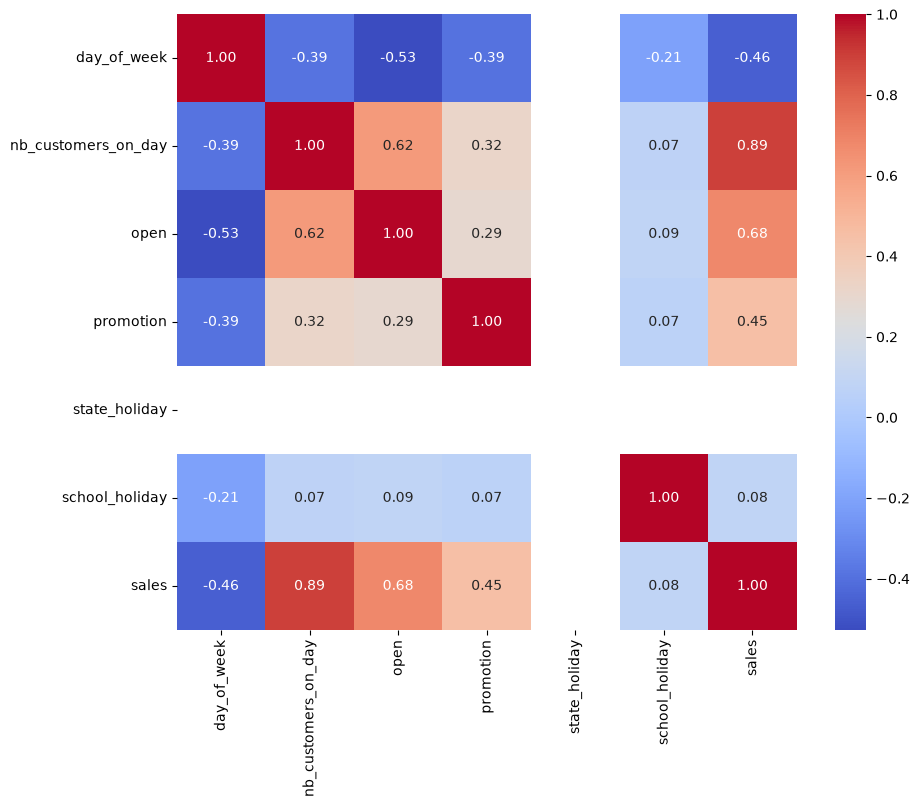

In [ ]:
#heat map of the correlation between the columns
plt.figure(figsize=(10, 8)) 

corr = df.drop(columns=["date"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

### "store_id" and "Unnamed 0" columns don't have an impact on sales (correlation = 0), so we drop them as they are not useful in the analysis.

In [ ]:
#drop the unnecessary columns from the data frame
#drop_columns =df.drop(columns=["Unnamed: 0", "store_ID"], inplace=True, )



In [ ]:
display(df)

,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,4,2013-04-18,517,1,0,0,0,4422
1,6,2015-04-11,694,1,0,0,0,8297
2,4,2013-08-29,970,1,1,0,0,9729
3,2,2013-05-28,473,1,1,0,0,6513
4,4,2013-10-10,1068,1,1,0,0,10882
...,...,...,...,...,...,...,...,...
640835,6,2013-10-26,483,1,0,0,0,4553
640836,1,2014-04-14,987,1,1,0,0,12307
640837,1,2014-07-07,925,1,0,0,0,6800
640838,4,2014-06-12,725,1,0,0,0,5344


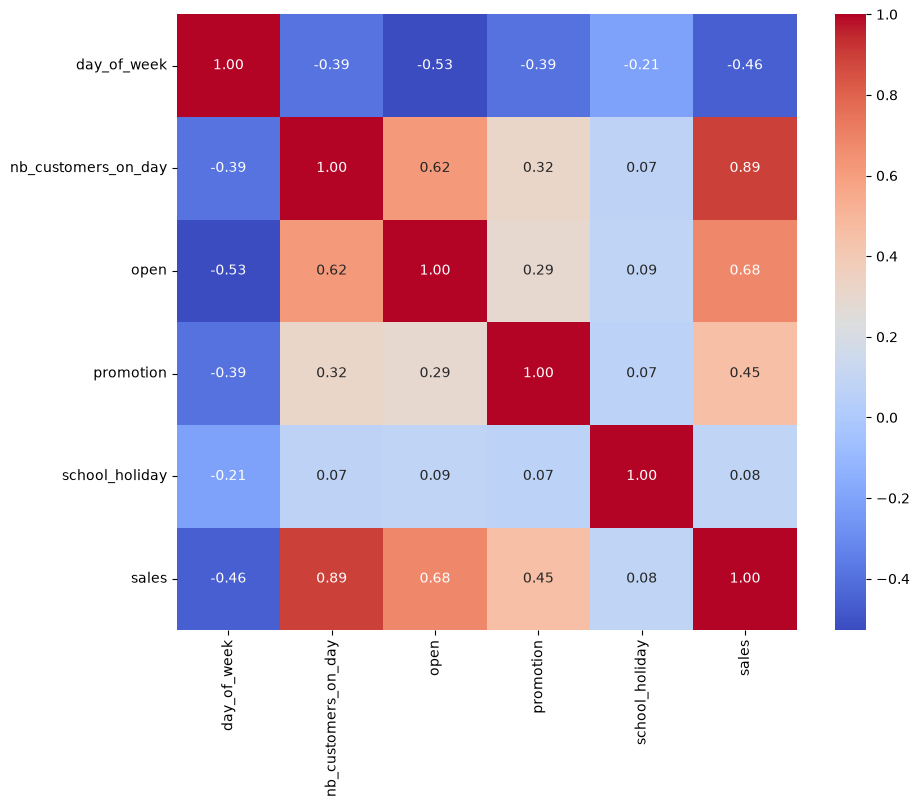

In [ ]:
#heat map of the correlation between the columns
plt.figure(figsize=(10, 8)) 

corr = df.drop(columns=["date", "state_holiday"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

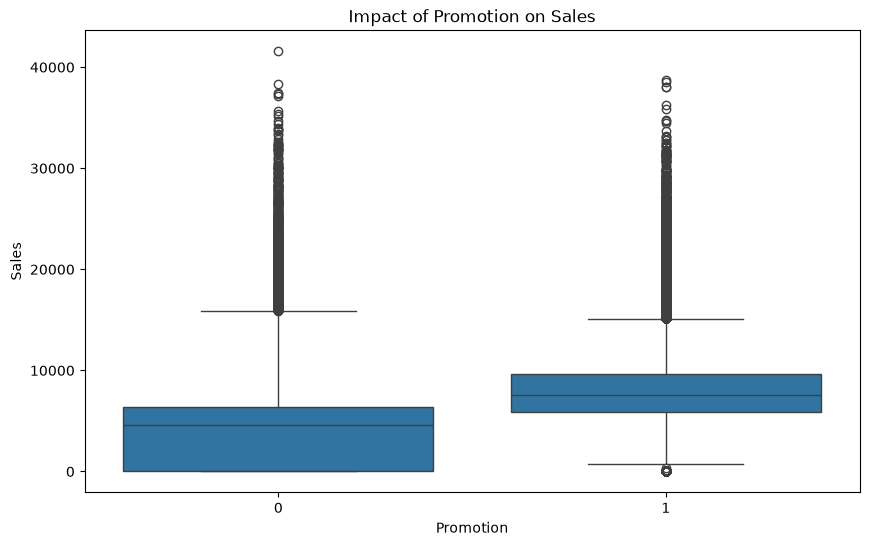

In [ ]:
#visualize the impact of Promotion on Sales using a boxplot 
plt.figure(figsize=(10, 6))
sns.boxplot(x=df["promotion"], y=df["sales"], data=df)  
plt.title("Impact of Promotion on Sales")
plt.xlabel("Promotion") 
plt.ylabel("Sales") 
plt.show()

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   day_of_week          640840 non-null  int64
 1   date                 640840 non-null  str  
 2   nb_customers_on_day  640840 non-null  int64
 3   open                 640840 non-null  int64
 4   promotion            640840 non-null  int64
 5   state_holiday        640840 non-null  str  
 6   school_holiday       640840 non-null  int64
 7   sales                640840 non-null  int64
dtypes: int64(6), str(2)
memory usage: 45.8 MB
